## LLM Usage
I have used LLMs in order to ask questions, have a better understanding, getting access to relevant documentation in order to solve the assignment and to get improvement ideas for the code.
### Personal details
Full Name: Jarl Dang <br>
Civic Number: 20010827-9191




## Dependencies
First pip install the following libraries; torch, transformers, peft
> pip install torch, transformers, peft

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model

c:\Users\jarld\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Process and load the data
First we need to process and load the data. As it was given, each review comes as a line together with a classifier at the start of the line. In order to tokenize it we first seperate the text and the classifier, thereafter we simply split the text on blank spaces.

In [2]:

def load_data(filepath):
    texts = []
    labels = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t", 1)
            if len(parts) == 2:
                labels.append(int(parts[0]))
                texts.append(parts[1])
    return texts, labels


train_texts, train_labels = load_data("data/ReviewBaseTraining.txt")
val_texts, val_labels = load_data("data/ReviewBaseValidation.txt")
test_texts, test_labels = load_data("data/ReviewBaseTest.txt")

print(f"Training samples: {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}")
print(f"Test samples: {len(test_texts)}")


Training samples: 10000
Validation samples: 5000
Test samples: 5000


## Setting up the model and applying LoRA
We specify the model name to be deberta-v3, since that is the version we want to use according to the assignment. There after we config the model using LoRA according to the documentation on kaggle and huggingface. This allows us to only fine tune a small number of parameters instead of all of them, immensly saving on computational power and time. The values chosen are standard values which are common for these kind of projects. The single fully connected layer after the transformer blocks is automatically incorporated in this model.

<br>
Then we tokenize the data in a way fitting for the

In [3]:

MODEL_NAME = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# https://www.kaggle.com/code/verifyitisyou/fine-tuning-deberta-large-with-lora-adapter
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query_proj", "value_proj"],
    lora_dropout=0.1,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=512)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=512)


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 963.56it/s, Materializing param=deberta.encoder.rel_embeddings.weight]                      
DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
pooler.dense.weight                     | MI

trainable params: 294,912 || all params: 184,718,594 || trainable%: 0.1597


## Dataset Wrapper
PyTorch's `DataLoader` requires data to be wrapped in a `Dataset` object. This class wraps the tokenized encodings and labels into a format compatible with PyTorch. The `__getitem__` method converts each sample's encodings and label into tensors on demand, while filtering out `token_type_ids` since DeBERTa-v3 does not use them. We then create dataset instances for training, validation, and test data.

In [4]:
class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
            if key != "token_type_ids"
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item


train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset = ReviewDataset(val_encodings, val_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)


## Making torch use the GPU
Utilising the GPU to compute is many, many times faster. In theory it is quite easy to make torch use the cpu, as seen by the following code block. One issue I had to troubleshoot was to ensure that the right installation of torch is installed and compatible with the relevant GPU. Another thing to note is that only NVIDA GPUs are valid, since they have CUDA cores. Ensure that the right version of torch is installed for the systems CUDA version, for example I had CUDA 13.xx meaning I had to install torch with the following command to get it to work:
> `pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu130`

In [5]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Using device:", device)


Using device: cuda


## Training the model

The setup for the model was written accodring to pytorch tutorials:
> https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html
<br>

First one needs to format the data correctly as a DataLoader class. Then we use the Adam optimizer with the models parameters. Then we can train the model as the code below specifies. We train the model for a maximum of 15 epochs (time constraint) and stop the training early if there is no improvement over 2 epochs. Usually training for more than 5 epochs leads to overfitting, but considering we are only training a small set of parameters, thanks to LoRA, it gives us some more leeway. We also have a very small learning rate which prevents overfitting.

In [6]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)
test_loader = DataLoader(test_dataset, batch_size=8)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
num_epochs = 3
best_val_accuracy = 0
patience = 2 
epochs_without_improvement = 0

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for i, batch in enumerate(train_loader):
        if i % 100 == 0:
            print(f"Epoch {epoch + 1}, Batch {i}/{len(train_loader)}")
        # This line to ensure they all train on the GPU, much quicker
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()

    # Validate
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=-1)
            correct += (preds == batch["labels"]).sum().item()
            total += len(batch["labels"])

    val_accuracy = correct / total
    print(
        f"Epoch {epoch + 1}/{num_epochs} - "
        f"Loss: {total_loss / len(train_loader):.4f} - "
        f"Val Accuracy: {val_accuracy:.4f}"
    )
    
    # Early stopping logic
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        epochs_without_improvement = 0
        # Save best model
        torch.save(model.state_dict(), "best_model.pt")
        print(f"New best model saved!")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs")
            break

Epoch 1, Batch 0/1250
Epoch 1, Batch 100/1250
Epoch 1, Batch 200/1250
Epoch 1, Batch 300/1250
Epoch 1, Batch 400/1250
Epoch 1, Batch 500/1250
Epoch 1, Batch 600/1250
Epoch 1, Batch 700/1250
Epoch 1, Batch 800/1250
Epoch 1, Batch 900/1250
Epoch 1, Batch 1000/1250
Epoch 1, Batch 1100/1250
Epoch 1, Batch 1200/1250
Epoch 1/3 - Loss: 0.6579 - Val Accuracy: 0.6782
New best model saved!
Epoch 2, Batch 0/1250
Epoch 2, Batch 100/1250
Epoch 2, Batch 200/1250
Epoch 2, Batch 300/1250
Epoch 2, Batch 400/1250
Epoch 2, Batch 500/1250
Epoch 2, Batch 600/1250
Epoch 2, Batch 700/1250
Epoch 2, Batch 800/1250
Epoch 2, Batch 900/1250
Epoch 2, Batch 1000/1250
Epoch 2, Batch 1100/1250
Epoch 2, Batch 1200/1250
Epoch 2/3 - Loss: 0.4418 - Val Accuracy: 0.7536
New best model saved!
Epoch 3, Batch 0/1250
Epoch 3, Batch 100/1250
Epoch 3, Batch 200/1250
Epoch 3, Batch 300/1250
Epoch 3, Batch 400/1250
Epoch 3, Batch 500/1250
Epoch 3, Batch 600/1250
Epoch 3, Batch 700/1250
Epoch 3, Batch 800/1250
Epoch 3, Batch 900/1

## Testing DeBERT
Note that we load the best model saved from the training session before testing. Now we test the trained model on the test data and we receive a `Test Accuracy: 0.9394`. It is interesting that the best model was the one which had been trained for all 15 epochs, suggesting that further training may improve upon the model even more.

In [7]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=-1)
        correct += (preds == batch["labels"]).sum().item()
        total += len(batch["labels"])

print(f"Test Accuracy: {correct / total:.4f}")


Test Accuracy: 0.8518


## Linear Perceptron
Now we try to classify the dataset using a linear perceptron and n-gram features instead. We will try and run the training for unigrams, bigrams and trigrams and evaluate the results for each value of n. We will also differ the minimum instance counts for each inlcusion.

Imports

In [8]:
import numpy as np
from collections import Counter


## Loading the data
We need to load the data in the same way as for the DeBERTa model.

In [9]:
def load_data(filepath):
    texts = []
    labels = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t", 1)
            if len(parts) == 2:
                labels.append(int(parts[0]))
                texts.append(parts[1])
    return texts, labels


train_texts, train_labels = load_data("data/ReviewBaseTraining.txt")
val_texts, val_labels = load_data("data/ReviewBaseValidation.txt")
test_texts, test_labels = load_data("data/ReviewBaseTest.txt")

print(
    f"Training: {len(train_texts)}, Validation: {len(val_texts)}, Test: {len(test_texts)}"
)


Training: 10000, Validation: 5000, Test: 5000


## The Linear Perceptron
We implement the linear perceptron as a class. In order to make it more efficent we utilise sparse dictionary representations, meaning we only store the non-zero features in a dictionary instead of storing everything in a full array. This is done since I had runtime problems when doing trigrams with a low instance count and therefore had to optimise the code.

During training the perceptron is trained as usual, the weights are updated immediately after each misclassification according to the algorithm. The training continues for a maximum number of epochs and stops early if we achieve zero errors on a complete pass through the data.

When predicting, the perceptron computes a linear score as the sum of the bias and weighted features and returns a 1 if the score is greater than zero, else it returns a 0.

In [10]:

class LinearPerceptron:
    def __init__(self, num_features, max_iter=100, lr=1.0):
        self.weights = np.zeros(num_features)
        self.bias = 0.0
        self.max_iter = max_iter
        self.lr = lr

    def predict_one(self, x_sparse):
        score = self.bias
        for idx, val in x_sparse.items():
            score += self.weights[idx] * val
        return 1 if score > 0 else 0

    def predict(self, X_sparse):
        return np.array([self.predict_one(x) for x in X_sparse])

    def fit(self, X_sparse, y):
        y = np.array(y)
        for epoch in range(self.max_iter):
            errors = 0
            for i in range(len(X_sparse)):
                pred = self.predict_one(X_sparse[i])
                if pred != y[i]:
                    update = self.lr * (y[i] - pred)
                    for idx, val in X_sparse[i].items():
                        self.weights[idx] += update * val
                    self.bias += update
                    errors += 1
            if errors == 0:
                break


## N-gram feature extraction
In order to use n-grams we need to define functions which extract the relevant n-grams from the text. This is done in the following code block.

In [11]:

def get_ngrams(text, n_max):
    """Extract all n-grams (1 up to n_max) from a space-separated text."""
    words = text.split()
    ngrams = []
    for n in range(1, n_max + 1):
        for i in range(len(words) - n + 1):
            ngrams.append(" ".join(words[i : i + n]))
    return ngrams


def build_vocabulary(texts, n_max, c_min):
    """Build a vocabulary of n-grams that appear at least c_min times."""
    counts = Counter()
    for text in texts:
        ngrams = get_ngrams(text, n_max)
        counts.update(ngrams)

    vocab = {}
    idx = 0
    for ngram, count in counts.items():
        if count >= c_min:
            vocab[ngram] = idx
            idx += 1
    return vocab


def texts_to_sparse_features(texts, vocab, n_max):
    """Convert texts to a list of sparse feature dicts {feature_index: count}."""
    sparse_data = []
    for text in texts:
        features = {}
        ngrams = get_ngrams(text, n_max)
        for ngram in ngrams:
            if ngram in vocab:
                idx = vocab[ngram]
                features[idx] = features.get(idx, 0) + 1
        sparse_data.append(features)
    return sparse_data


## Main simulation and training loop
Now we do a grid search in order to find the optimal c values for each n-gram. 

In [12]:

def accuracy(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))

n_max_values = [1, 2, 3]
c_min_values = [1, 3, 10, 100]

best_models = {}

for n_max in n_max_values:
    best_val_acc = 0
    best_c_min = None
    best_model = None
    best_vocab = None

    print(f"\n{'=' * 50}")
    print(f"n_max = {n_max}")
    print(f"{'=' * 50}")

    for c_min in c_min_values:
        vocab = build_vocabulary(train_texts, n_max, c_min)
        num_features = len(vocab)

        X_train = texts_to_sparse_features(train_texts, vocab, n_max)
        X_val = texts_to_sparse_features(val_texts, vocab, n_max)

        model = LinearPerceptron(num_features, max_iter=100)
        model.fit(X_train, train_labels)

        val_preds = model.predict(X_val)
        val_acc = accuracy(val_labels, val_preds)

        print(
            f"  c_min={c_min:>3d} | features: {num_features:>6d} | Val Accuracy: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_c_min = c_min
            best_model = model
            best_vocab = vocab

    best_models[n_max] = (best_model, best_vocab, best_c_min, best_val_acc)



n_max = 1
  c_min=  1 | features:  61047 | Val Accuracy: 0.8016
  c_min=  3 | features:  28300 | Val Accuracy: 0.8342
  c_min= 10 | features:  12909 | Val Accuracy: 0.8332
  c_min=100 | features:   2139 | Val Accuracy: 0.8102

n_max = 2
  c_min=  1 | features: 757761 | Val Accuracy: 0.8592
  c_min=  3 | features: 151048 | Val Accuracy: 0.8622
  c_min= 10 | features:  44960 | Val Accuracy: 0.8584
  c_min=100 | features:   4691 | Val Accuracy: 0.8296

n_max = 3
  c_min=  1 | features: 2460788 | Val Accuracy: 0.8656
  c_min=  3 | features: 267901 | Val Accuracy: 0.8550
  c_min= 10 | features:  64688 | Val Accuracy: 0.8544
  c_min=100 | features:   5433 | Val Accuracy: 0.8204


## Test Accuracy
Now we extract the best model for each n-gram and run it on the test data in order to get the test accuracy score.

In [13]:

print(f"\n{'=' * 50}")
print("Test set results (best model per n_max)")
print(f"{'=' * 50}")

for n_max in n_max_values:
    model, vocab, c_min, val_acc = best_models[n_max]
    X_test = texts_to_sparse_features(test_texts, vocab, n_max)
    test_preds = model.predict(X_test)
    test_acc = accuracy(test_labels, test_preds)

    print(
        f"  n_max={n_max} | best c_min={c_min:>3d} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}"
    )



Test set results (best model per n_max)
  n_max=1 | best c_min=  3 | Val Acc: 0.8342 | Test Acc: 0.8566
  n_max=2 | best c_min=  3 | Val Acc: 0.8622 | Test Acc: 0.8830
  n_max=3 | best c_min=  1 | Val Acc: 0.8656 | Test Acc: 0.8812


## Task 4: N-gram Weight Visualization and Coverage Ratio

We visualize the perceptron models' decision-making by plotting all n-gram features as bars: green for positive weights (indicating positive sentiment), red for negative weights (indicating negative sentiment). The bar length is proportional to the weight magnitude. N-grams that do not appear in the text are shown without any bar, allowing us to visually assess coverage.

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def plot_ngram_weights(text, model, vocab, n_max, title=""):
    """
    Plot all n-grams extracted from the text.
    - Green bar for positive weights, red bar for negative weights (n-gram in vocab).
    - No bar for n-grams not in the vocabulary, to assess coverage ratio.
    """
    # Get all unique n-grams from this text
    text_ngrams = list(dict.fromkeys(get_ngrams(text, n_max)))

    features = []
    for ngram in text_ngrams:
        if ngram in vocab:
            weight = model.weights[vocab[ngram]]
            features.append((ngram, weight, True))
        else:
            features.append((ngram, 0.0, False))

    # Sort: positive weights at top, then zero/not-in-vocab, then negative
    features.sort(key=lambda x: x[1], reverse=True)

    ngram_names = [f[0] for f in features]
    weights = [f[1] for f in features]
    in_vocab = [f[2] for f in features]

    colors = []
    bar_weights = []
    for w, v in zip(weights, in_vocab):
        if not v:
            colors.append("white")
            bar_weights.append(0)
        elif w >= 0:
            colors.append("green")
            bar_weights.append(w)
        else:
            colors.append("red")
            bar_weights.append(w)

    fig_height = max(4, len(features) * 0.25)
    fig, ax = plt.subplots(figsize=(10, fig_height))

    y_pos = range(len(ngram_names))
    ax.barh(y_pos, bar_weights, color=colors, edgecolor="lightgray", linewidth=0.3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ngram_names, fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel("Weight")
    ax.set_title(title if title else "N-gram weights for review")

    green_patch = mpatches.Patch(color="green", label="Positive weight (in vocab)")
    red_patch = mpatches.Patch(color="red", label="Negative weight (in vocab)")
    white_patch = mpatches.Patch(
        facecolor="white", edgecolor="gray", label="Not in vocabulary"
    )
    ax.legend(
        handles=[green_patch, red_patch, white_patch], loc="lower right", fontsize=8
    )

    plt.tight_layout()
    plt.show()


### Applying the visualizer to short reviews
We select 4 short reviews from the test set (the shortest available) and visualize the n-gram weights for the linear perceptrion where n_max = 3. This way we can see unigrams, bigrams, and trigrams and how they impact the classicifaction.

Review 1109 (Positive, 19 words): Add this little gem to your list of holiday regulars . It is sweet , funny , and endearing

Review 4474 (Negative, 26 words): Ten minutes of people spewing gallons of pink vomit . Recurring scenes of enormous piles of dog excrement - need one say more ? ? ?

Review 4668 (Negative, 28 words): Hated it with all my being . Worst movie ever . Mentally - scarred . Help me . It was that bad . TRUST ME ! ! !

Review 2441 (Positive, 29 words): A great film in its genre , the direction , acting , most especially the casting of the film makes it even more powerful . A must see .


Model: n_max=3, best c_min=1, vocab size=2460788


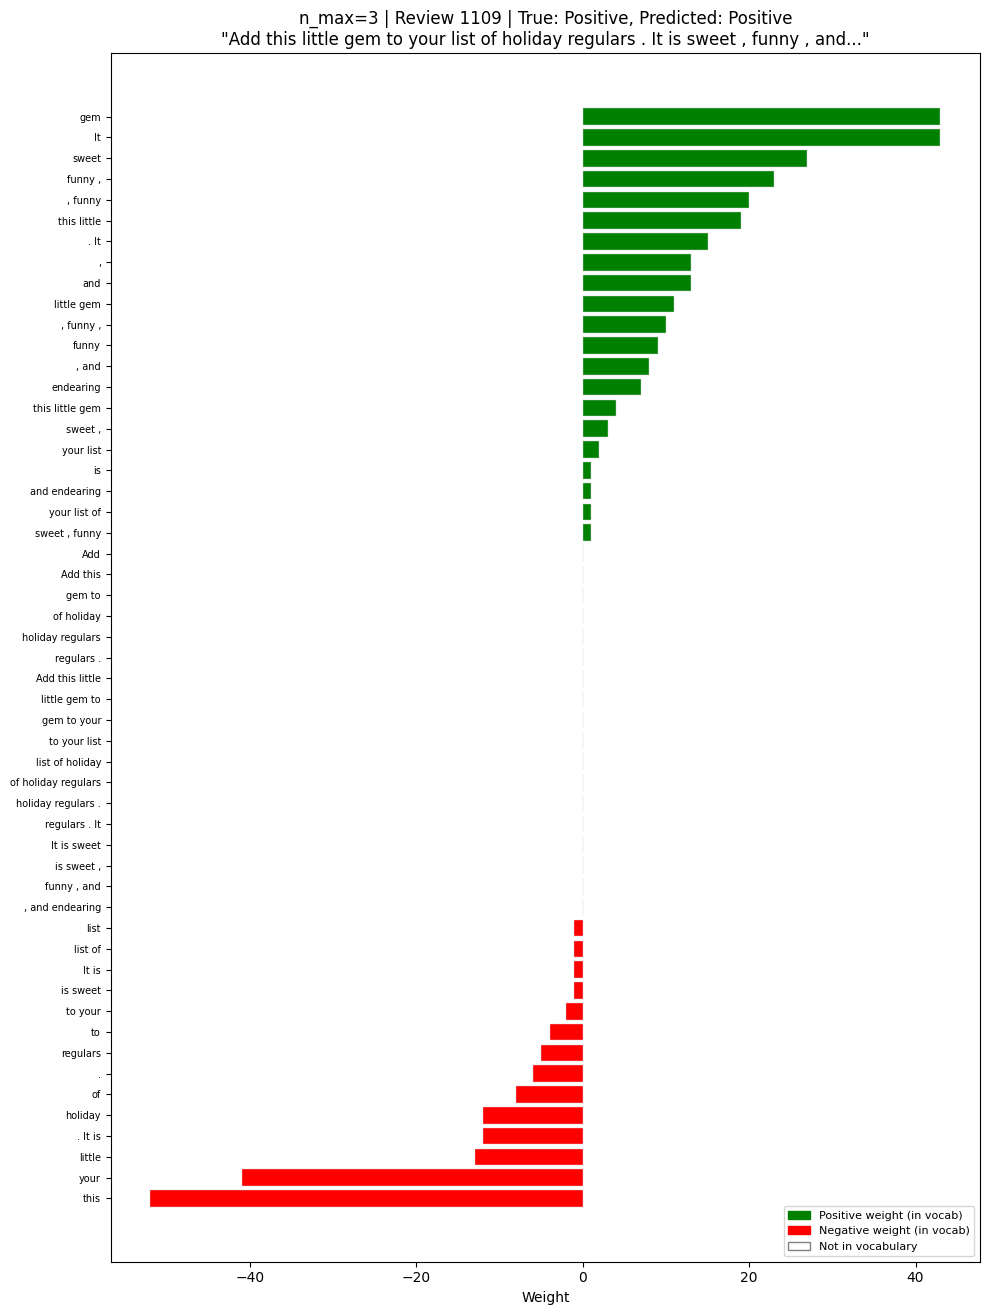

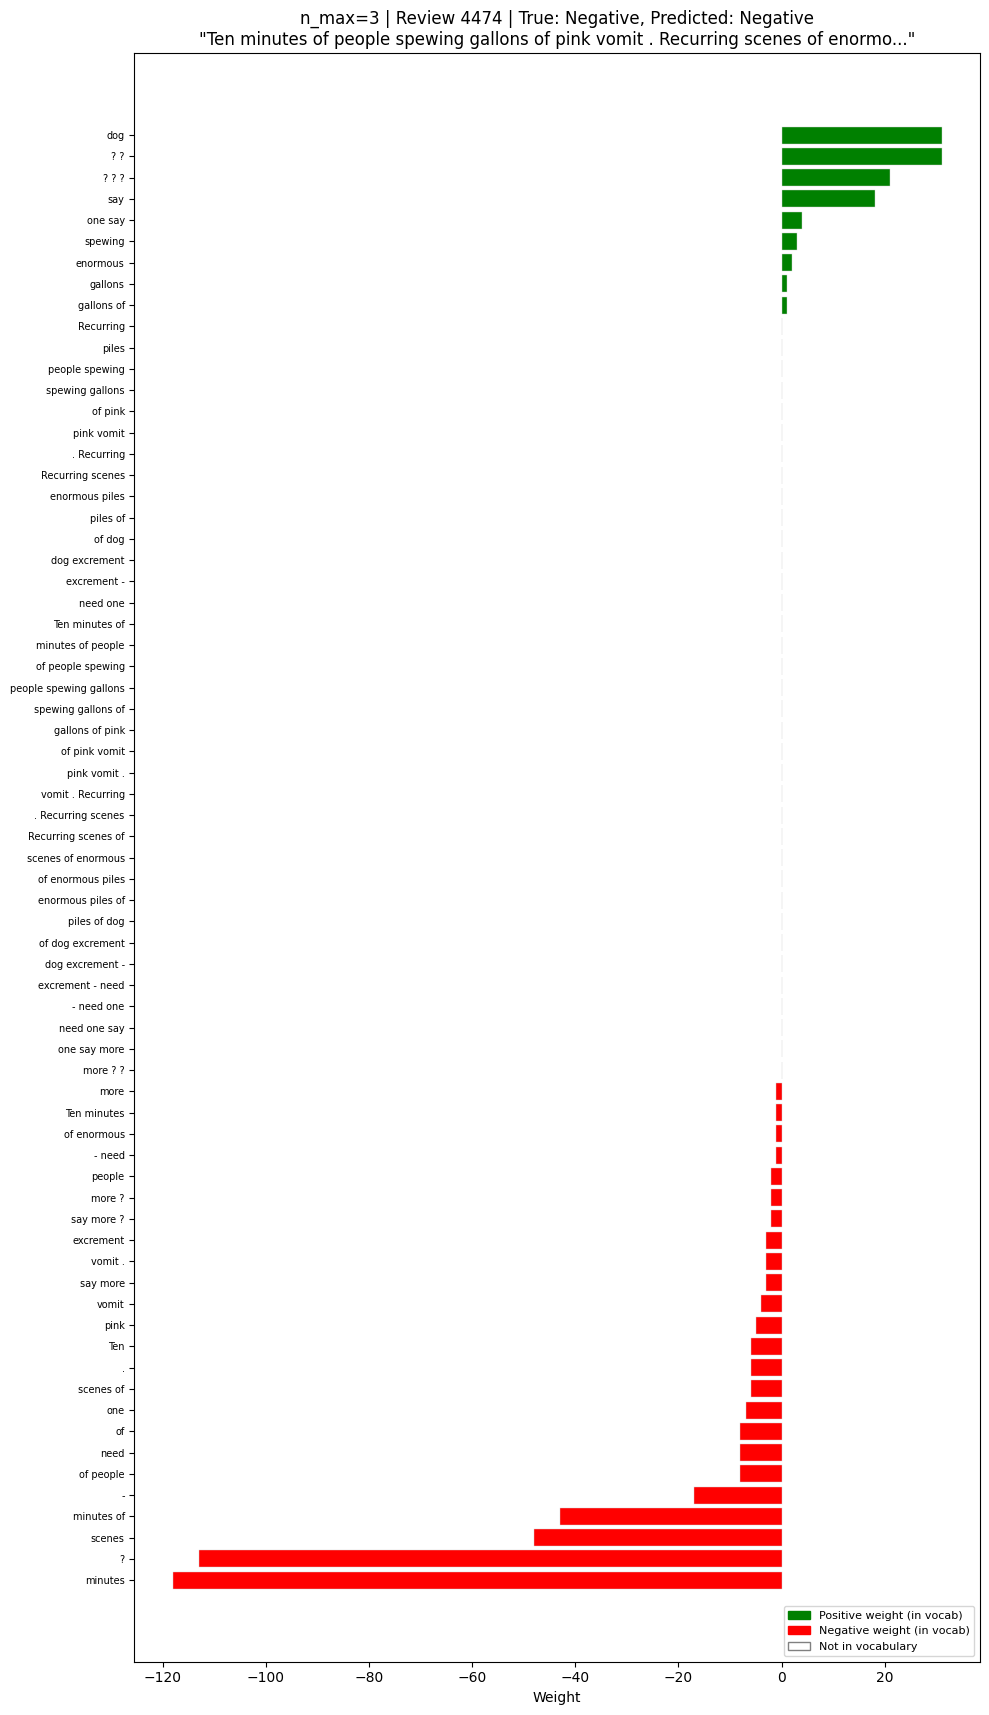

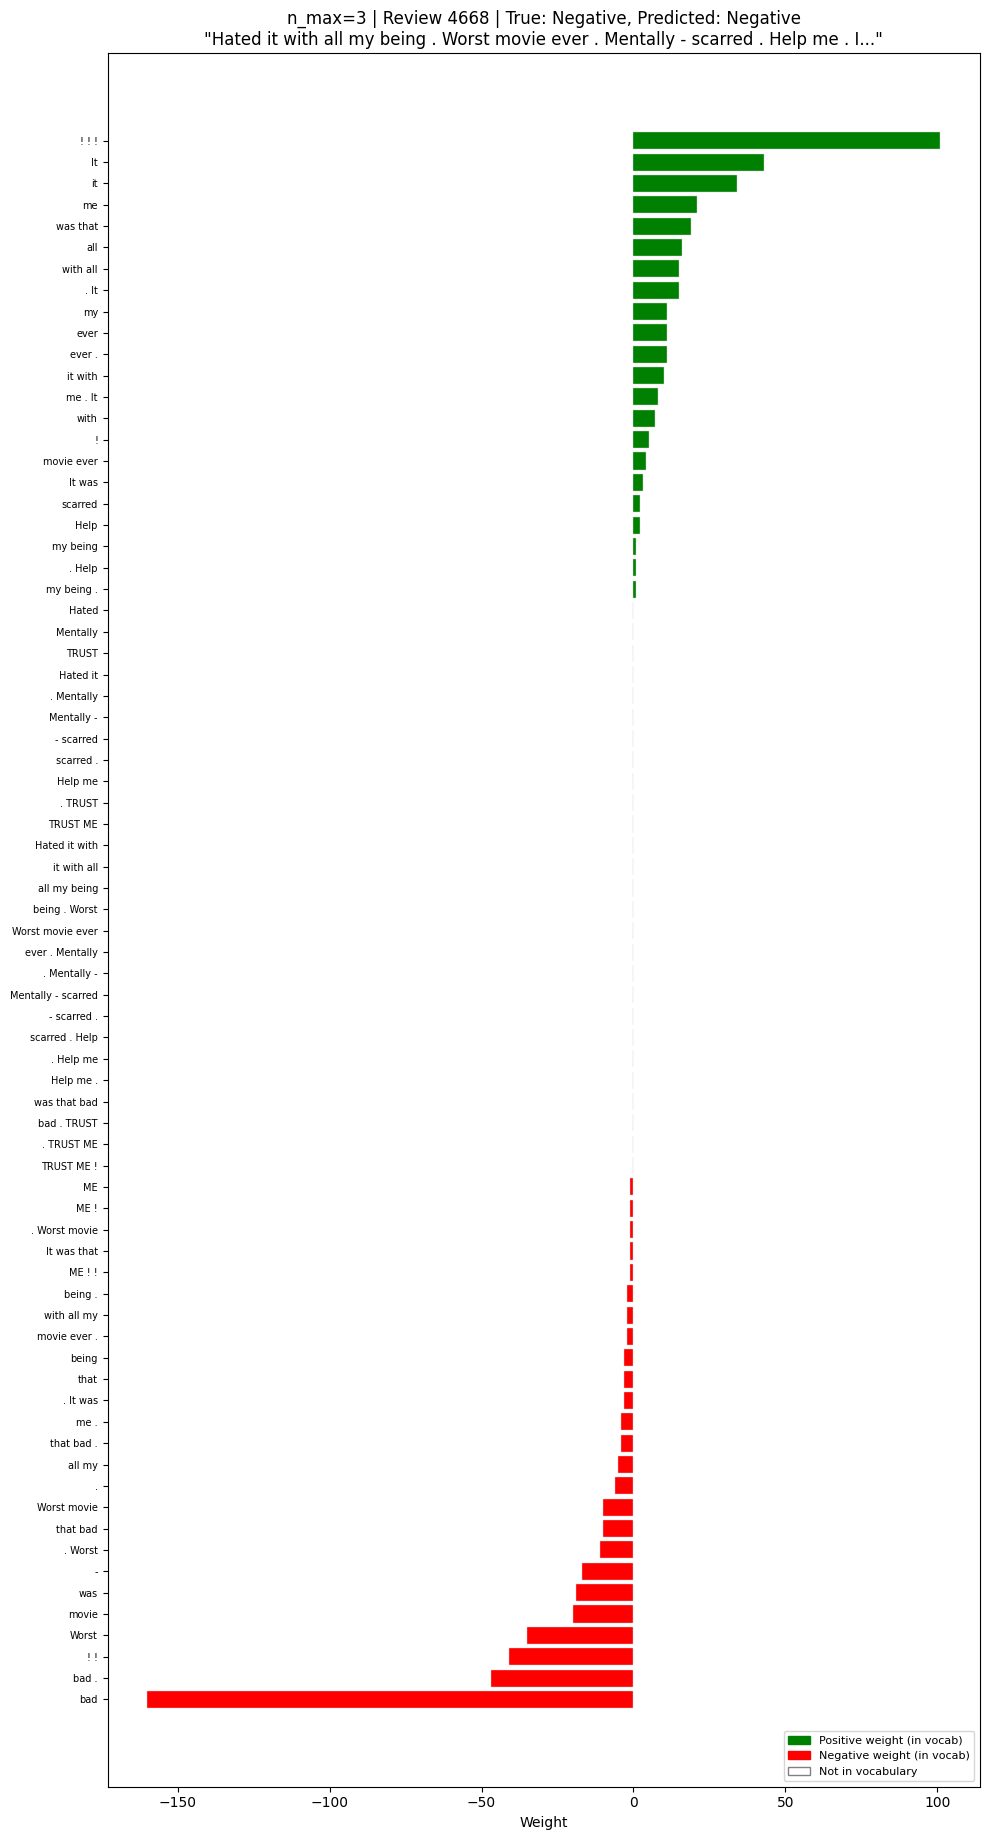

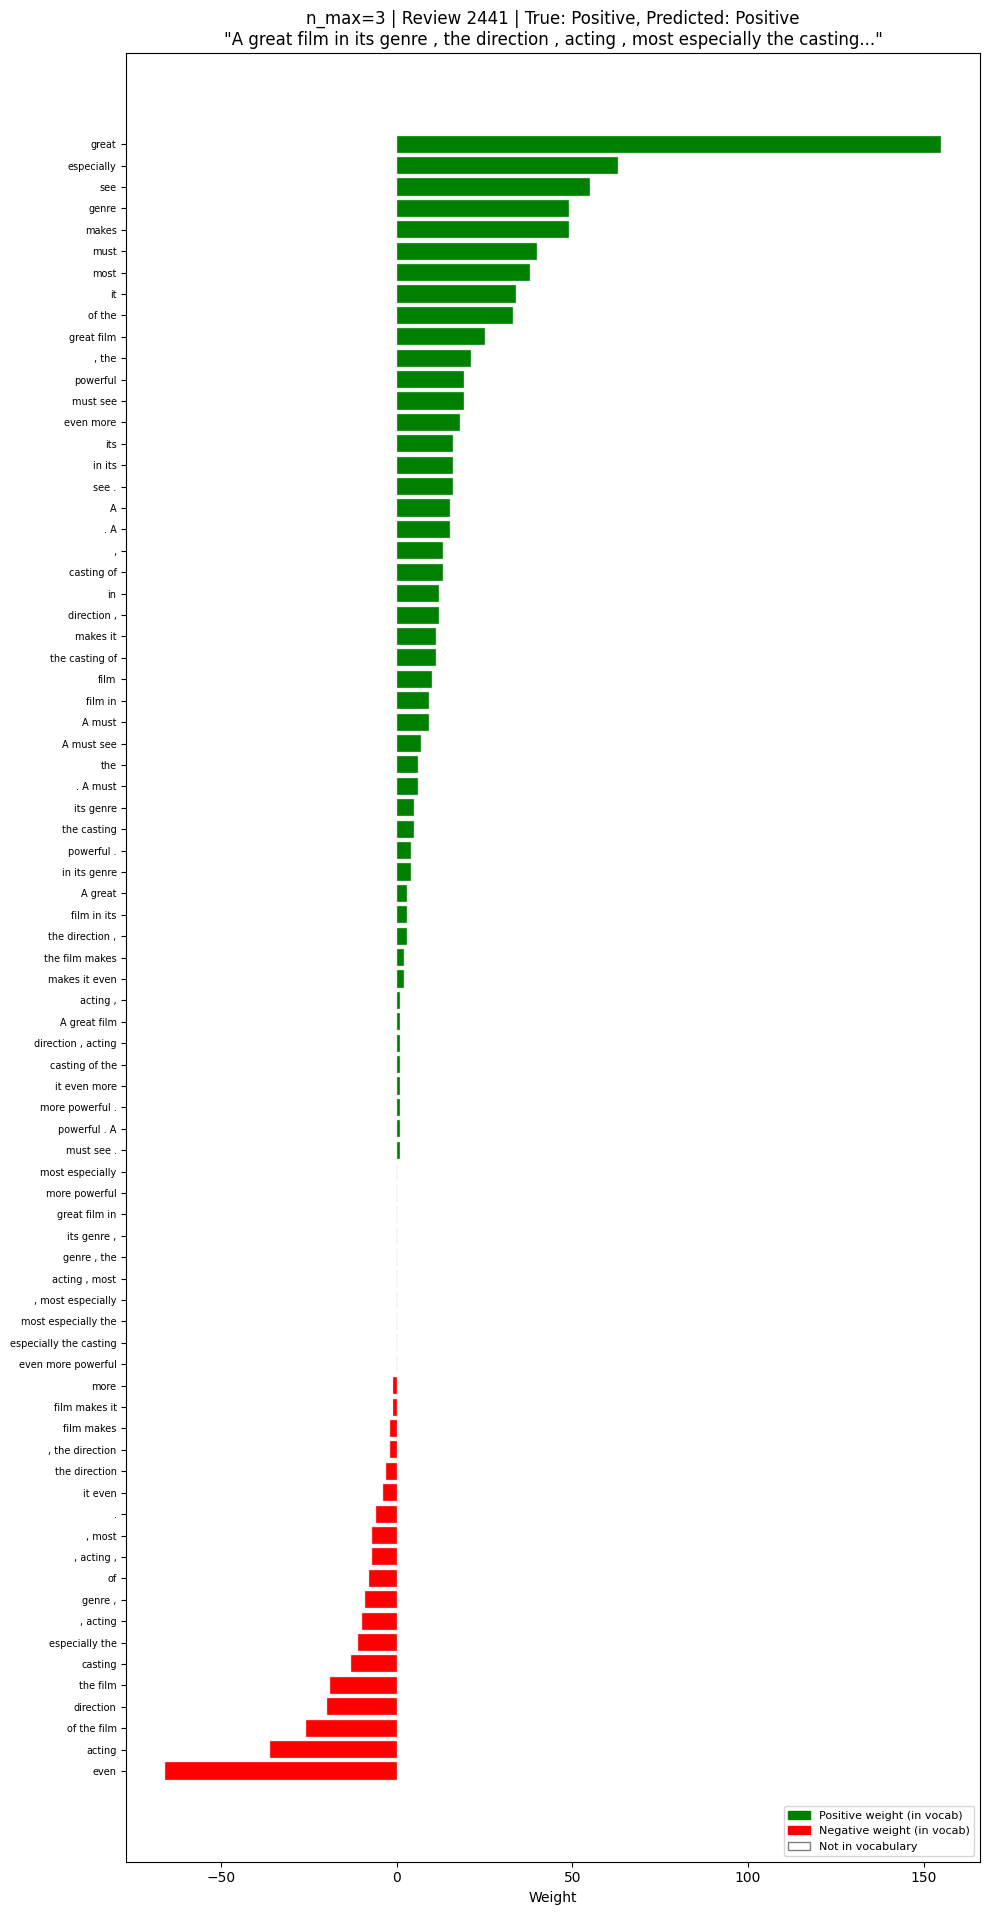

In [15]:
short_review_indices = [1109, 4474, 4668, 2441]

short_reviews = [
    (idx, test_labels[idx], test_texts[idx]) for idx in short_review_indices
]

for idx, label, text in short_reviews:
    word_count = len(text.split())
    sentiment = "Positive" if label == 1 else "Negative"
    print(f"Review {idx} ({sentiment}, {word_count} words): {text}\n")

n_max = 3
perc_model, vocab, c_min, val_acc = best_models[n_max]
print(f"\n{'=' * 60}")
print(f"Model: n_max={n_max}, best c_min={c_min}, vocab size={len(vocab)}")
print(f"{'=' * 60}")
for idx, label, text in short_reviews:
    sentiment = "Positive" if label == 1 else "Negative"
    pred = perc_model.predict_one(texts_to_sparse_features([text], vocab, n_max)[0])
    pred_str = "Positive" if pred == 1 else "Negative"
    title = (
        f"n_max={n_max} | Review {idx} | "
        f'True: {sentiment}, Predicted: {pred_str}\n"{text[:80]}..."'
    )
    plot_ngram_weights(text, perc_model, vocab, n_max, title=title)

### Coverage Ratio
The coverage ratio measures how much of the input text is covered by the model's vocabulary. For each review, it is the fraction of n-grams in the text that are present in the vocabulary. We compute the average coverage ratio over the entire test set for each linear perceptron model.

-  n_max=1 | c_min=  3 | Coverage: 0.9719
-  n_max=2 | c_min=  3 | Coverage: 0.8414
-  n_max=3 | c_min=  1 | Coverage: 0.7466

In [16]:
print(f"\n{'=' * 50}")
print("Coverage ratio over the test set")
print(f"{'=' * 50}")

for n_max in n_max_values:
    model, vocab, c_min, val_acc = best_models[n_max]
    total_ngrams = 0
    covered_ngrams = 0
    for text in test_texts:
        ngrams = get_ngrams(text, n_max)
        total_ngrams += len(ngrams)
        covered_ngrams += sum(1 for ng in ngrams if ng in vocab)
    coverage = covered_ngrams / total_ngrams
    print(f"  n_max={n_max} | c_min={c_min:>3d} | Coverage: {coverage:.4f}")



Coverage ratio over the test set
  n_max=1 | c_min=  3 | Coverage: 0.9719
  n_max=2 | c_min=  3 | Coverage: 0.8414
  n_max=3 | c_min=  1 | Coverage: 0.7466


## Task 5: Extending the Training Set

To make a fairer comparison, we extend the training set using the ReviewExtended dataset. We train linear perceptron models with n_max = 1, 2, 3 on the extended set, selecting the best c_min per n via validation accuracy on the extended validation set.

Then, for each n, we average the weights from the base model (w_b) and extended model (w_e) as:

$$w_c = \alpha \cdot w_b + (1 - \alpha) \cdot w_e$$

Where an n-gram only exists in one model, we use that weight directly. We search over several α values and select the one maximizing accuracy on the **base** validation set.

In [17]:

# Load extended dataset
ext_train_texts, ext_train_labels = load_data("data/ReviewExtendedTraining.txt")
ext_val_texts, ext_val_labels = load_data("data/ReviewExtendedValidation.txt")
print(f"Extended Training: {len(ext_train_texts)}, Extended Validation: {len(ext_val_texts)}")

# Train perceptron models on extended data with grid search over c_min
ext_best_models = {}

for n_max in n_max_values:
    best_val_acc = 0
    best_c_min = None
    best_model_ext = None
    best_vocab_ext = None

    print(f"\n{'='*50}")
    print(f"Extended set | n_max = {n_max}")
    print(f"{'='*50}")

    for c_min in c_min_values:
        vocab = build_vocabulary(ext_train_texts, n_max, c_min)
        num_features = len(vocab)

        X_train = texts_to_sparse_features(ext_train_texts, vocab, n_max)
        X_val = texts_to_sparse_features(ext_val_texts, vocab, n_max)

        perc = LinearPerceptron(num_features, max_iter=100)
        perc.fit(X_train, ext_train_labels)

        val_preds = perc.predict(X_val)
        val_acc = accuracy(ext_val_labels, val_preds)

        print(f"  c_min={c_min:>3d} | features: {num_features:>6d} | Val Accuracy: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_c_min = c_min
            best_model_ext = perc
            best_vocab_ext = vocab

    ext_best_models[n_max] = (best_model_ext, best_vocab_ext, best_c_min, best_val_acc)

# Weight averaging and alpha search
alpha_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

print(f"\n{'='*60}")
print("Weight averaging: w_c = alpha * w_b + (1-alpha) * w_e")
print(f"Evaluating on BASE validation set")
print(f"{'='*60}")

for n_max in n_max_values:
    base_model, base_vocab, base_cmin, base_val_acc = best_models[n_max]
    ext_model, ext_vocab, ext_cmin, ext_val_acc = ext_best_models[n_max]

    # Build combined vocabulary (union of base and extended)
    all_ngrams = set(base_vocab.keys()) | set(ext_vocab.keys())
    combined_vocab = {ngram: idx for idx, ngram in enumerate(sorted(all_ngrams))}
    num_combined = len(combined_vocab)

    # Map base weights into combined space
    base_weights_combined = np.zeros(num_combined)
    base_bias = base_model.bias
    base_ngram_set = set()
    for ngram, old_idx in base_vocab.items():
        new_idx = combined_vocab[ngram]
        base_weights_combined[new_idx] = base_model.weights[old_idx]
        base_ngram_set.add(ngram)

    # Map extended weights into combined space
    ext_weights_combined = np.zeros(num_combined)
    ext_bias = ext_model.bias
    ext_ngram_set = set()
    for ngram, old_idx in ext_vocab.items():
        new_idx = combined_vocab[ngram]
        ext_weights_combined[new_idx] = ext_model.weights[old_idx]
        ext_ngram_set.add(ngram)

    # Precompute base validation features in combined vocab space
    X_val_combined = texts_to_sparse_features(val_texts, combined_vocab, n_max)

    best_alpha = 0
    best_alpha_acc = 0

    print(f"\nn_max = {n_max} | base c_min={base_cmin}, ext c_min={ext_cmin} | combined features: {num_combined}")

    for alpha in alpha_values:
        # Compute combined weights
        combined_weights = np.zeros(num_combined)
        for ngram, idx in combined_vocab.items():
            in_base = ngram in base_ngram_set
            in_ext = ngram in ext_ngram_set
            if in_base and in_ext:
                combined_weights[idx] = alpha * base_weights_combined[idx] + (1 - alpha) * ext_weights_combined[idx]
            elif in_base:
                combined_weights[idx] = base_weights_combined[idx]
            else:
                combined_weights[idx] = ext_weights_combined[idx]

        combined_bias = alpha * base_bias + (1 - alpha) * ext_bias

        # Create a combined model
        combined_model = LinearPerceptron(num_combined)
        combined_model.weights = combined_weights
        combined_model.bias = combined_bias

        # Evaluate on base validation set
        val_preds = combined_model.predict(X_val_combined)
        val_acc = accuracy(val_labels, val_preds)

        print(f"  alpha={alpha:.1f} | Val Accuracy: {val_acc:.4f}")

        if val_acc > best_alpha_acc:
            best_alpha_acc = val_acc
            best_alpha = alpha

    print(f"  >> Best alpha={best_alpha:.1f} | Best Val Accuracy: {best_alpha_acc:.4f}")


Extended Training: 200000, Extended Validation: 100000

Extended set | n_max = 1
  c_min=  1 | features: 120939 | Val Accuracy: 0.8253
  c_min=  3 | features:  38820 | Val Accuracy: 0.7527
  c_min= 10 | features:  16930 | Val Accuracy: 0.7715
  c_min=100 | features:   3417 | Val Accuracy: 0.8263

Extended set | n_max = 2
  c_min=  1 | features: 1180709 | Val Accuracy: 0.8544
  c_min=  3 | features: 221643 | Val Accuracy: 0.8557
  c_min= 10 | features:  70387 | Val Accuracy: 0.8514
  c_min=100 | features:   8954 | Val Accuracy: 0.8428

Extended set | n_max = 3
  c_min=  1 | features: 3811228 | Val Accuracy: 0.8573
  c_min=  3 | features: 438974 | Val Accuracy: 0.8546
  c_min= 10 | features: 115068 | Val Accuracy: 0.8510
  c_min=100 | features:  11350 | Val Accuracy: 0.8366

Weight averaging: w_c = alpha * w_b + (1-alpha) * w_e
Evaluating on BASE validation set

n_max = 1 | base c_min=3, ext c_min=100 | combined features: 28483
  alpha=0.0 | Val Accuracy: 0.8142
  alpha=0.1 | Val Accurac

## Task 6: Test set evaluation, visualization and coverage for extended models
We rebuild the combined models using the best alpha per n_max found above, evaluate them on the base test set, and compare with the DeBERTa and base perceptron results. We also re-plot the same 4 short reviews from Step 4 and compute coverage ratios.

Model                               |  Val Acc | Test Acc
DeBERTa-v3 (LoRA fine-tuned)        |        — |   0.9394
Base perceptron n=1 c=3             |   0.8342 |   0.8566
Base perceptron n=2 c=3             |   0.8622 |   0.8830
Base perceptron n=3 c=1             |   0.8656 |   0.8812
Extended perceptron n=1 α=0.5       |   0.8542 |   0.8744
Extended perceptron n=2 α=0.5       |   0.8790 |   0.8966
Extended perceptron n=3 α=0.7       |   0.8742 |   0.8900

Visualization of extended models on the same 4 short reviews


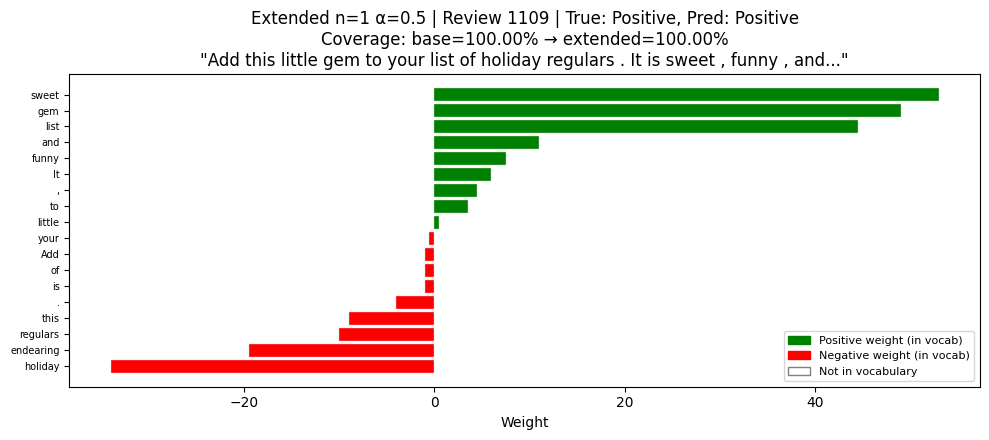

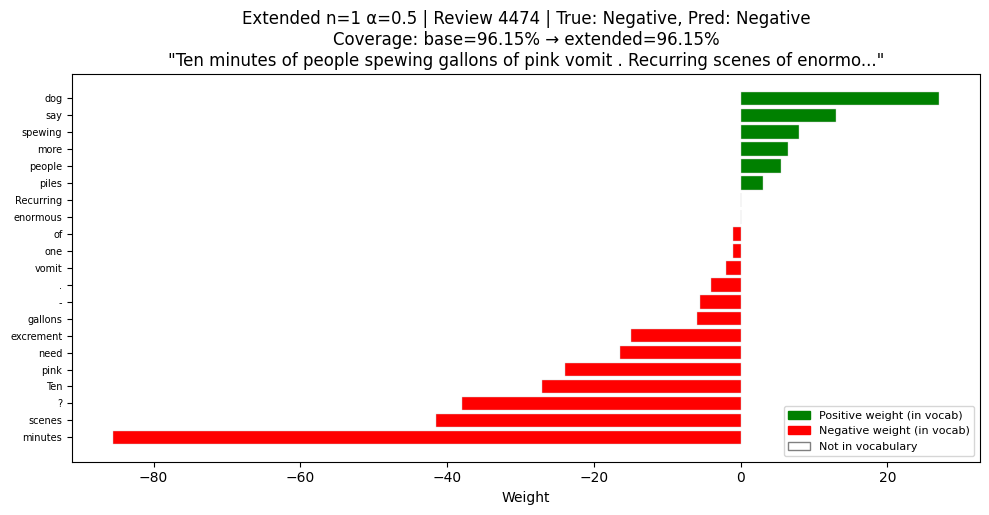

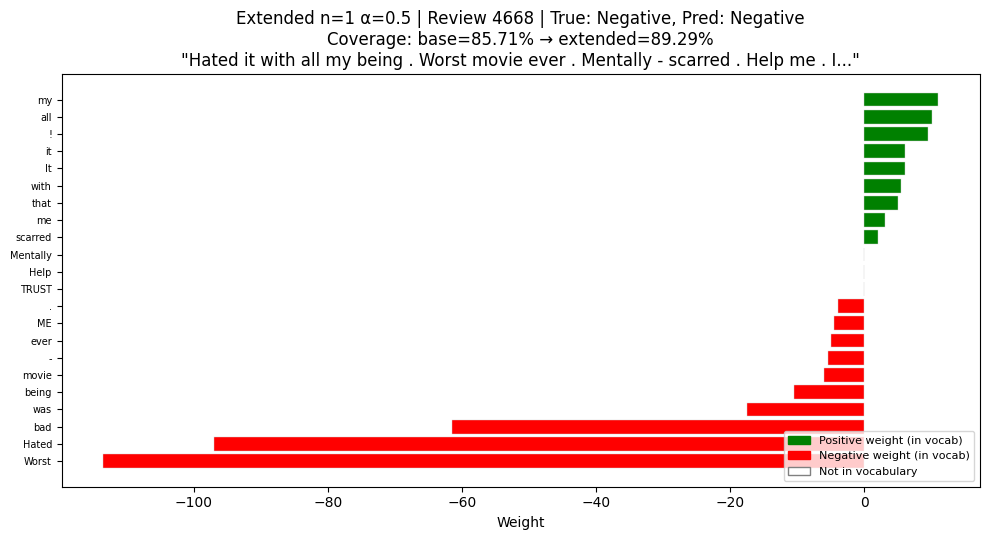

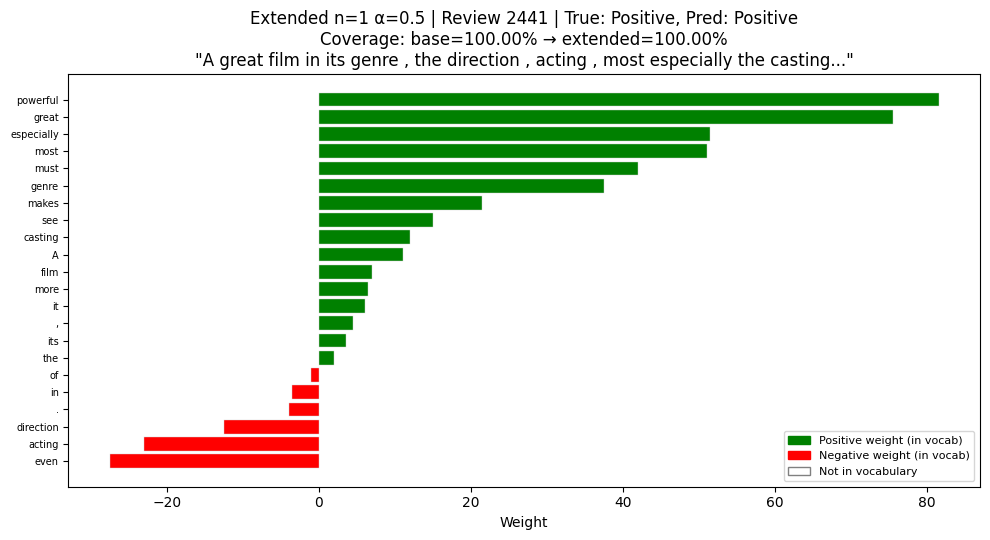

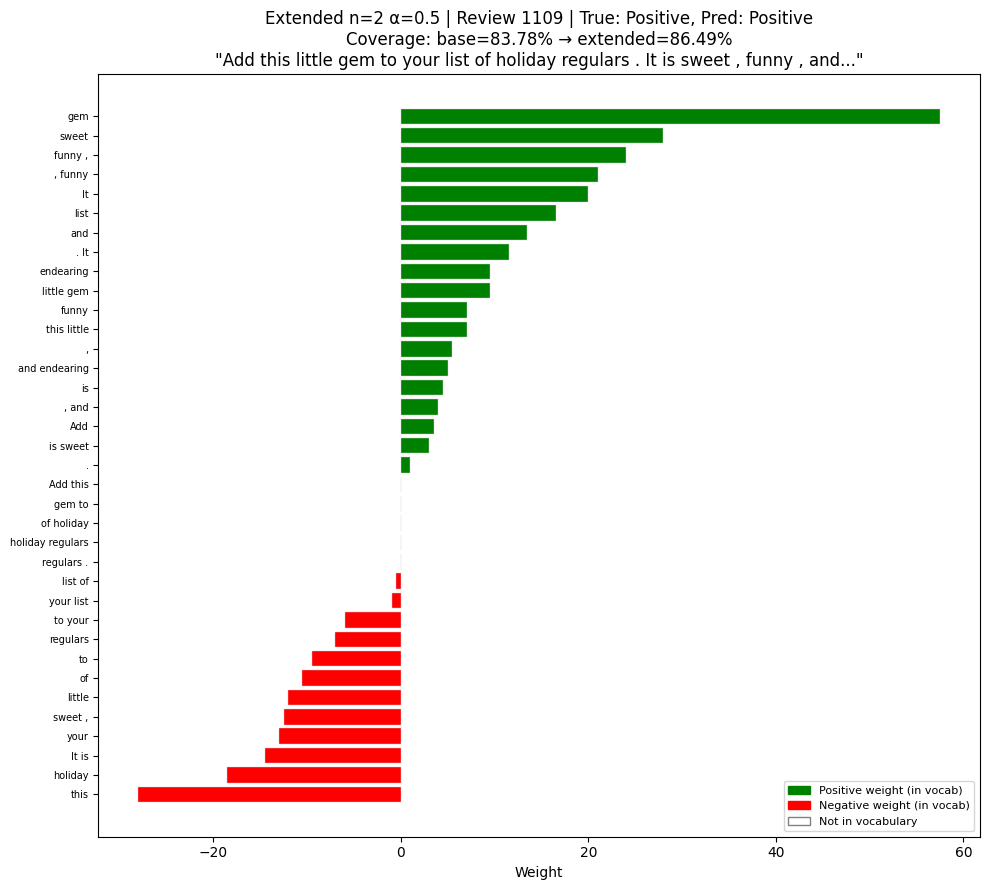

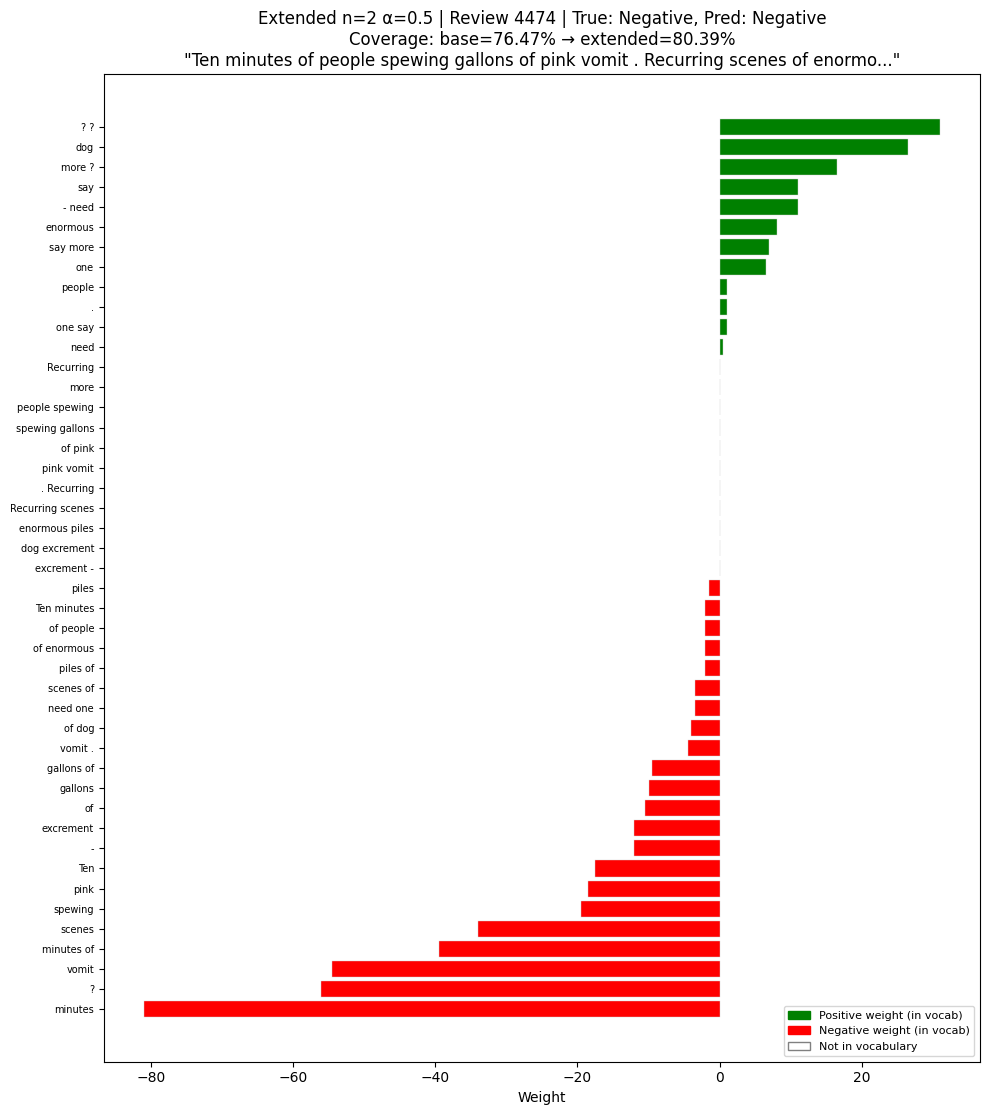

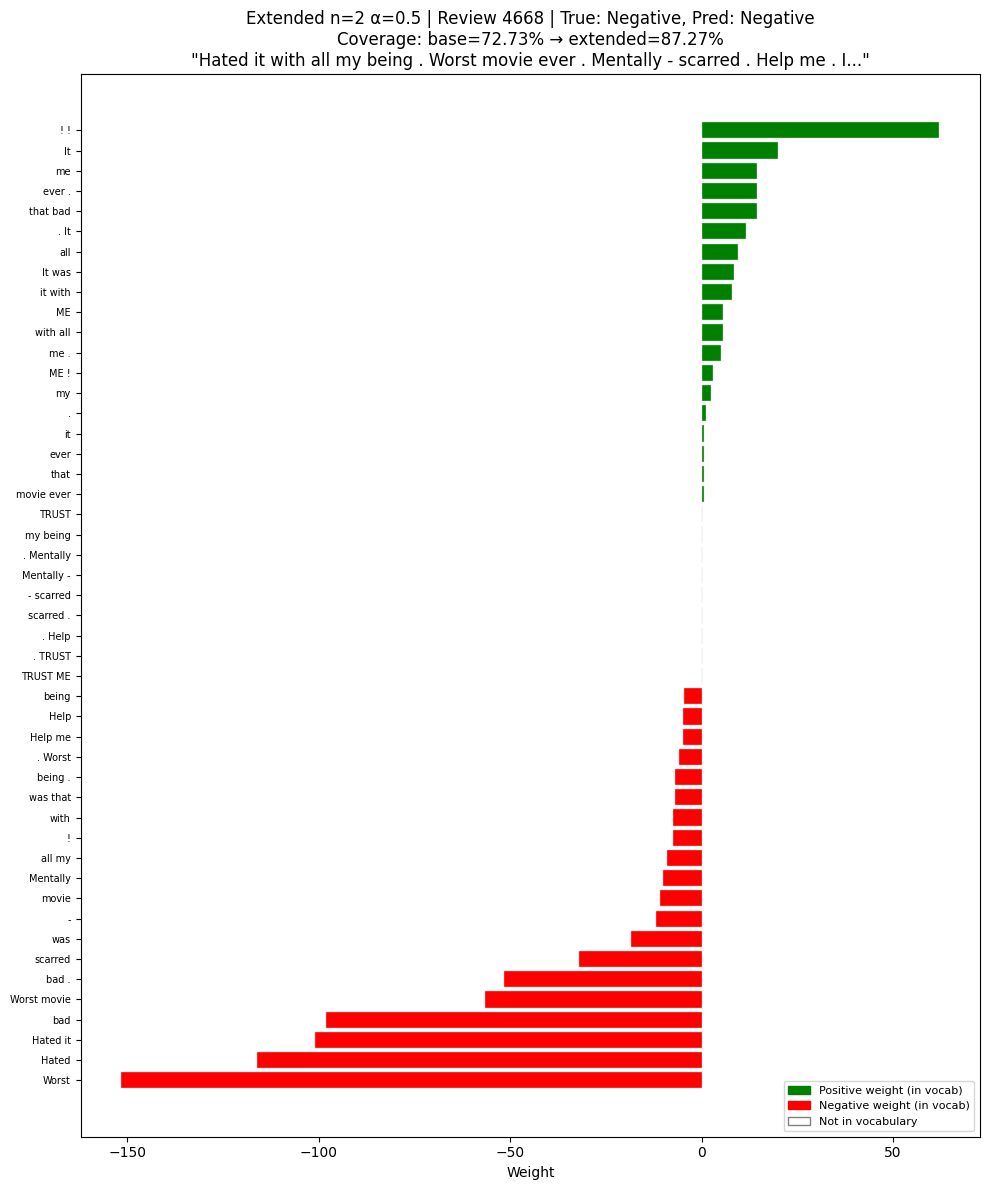

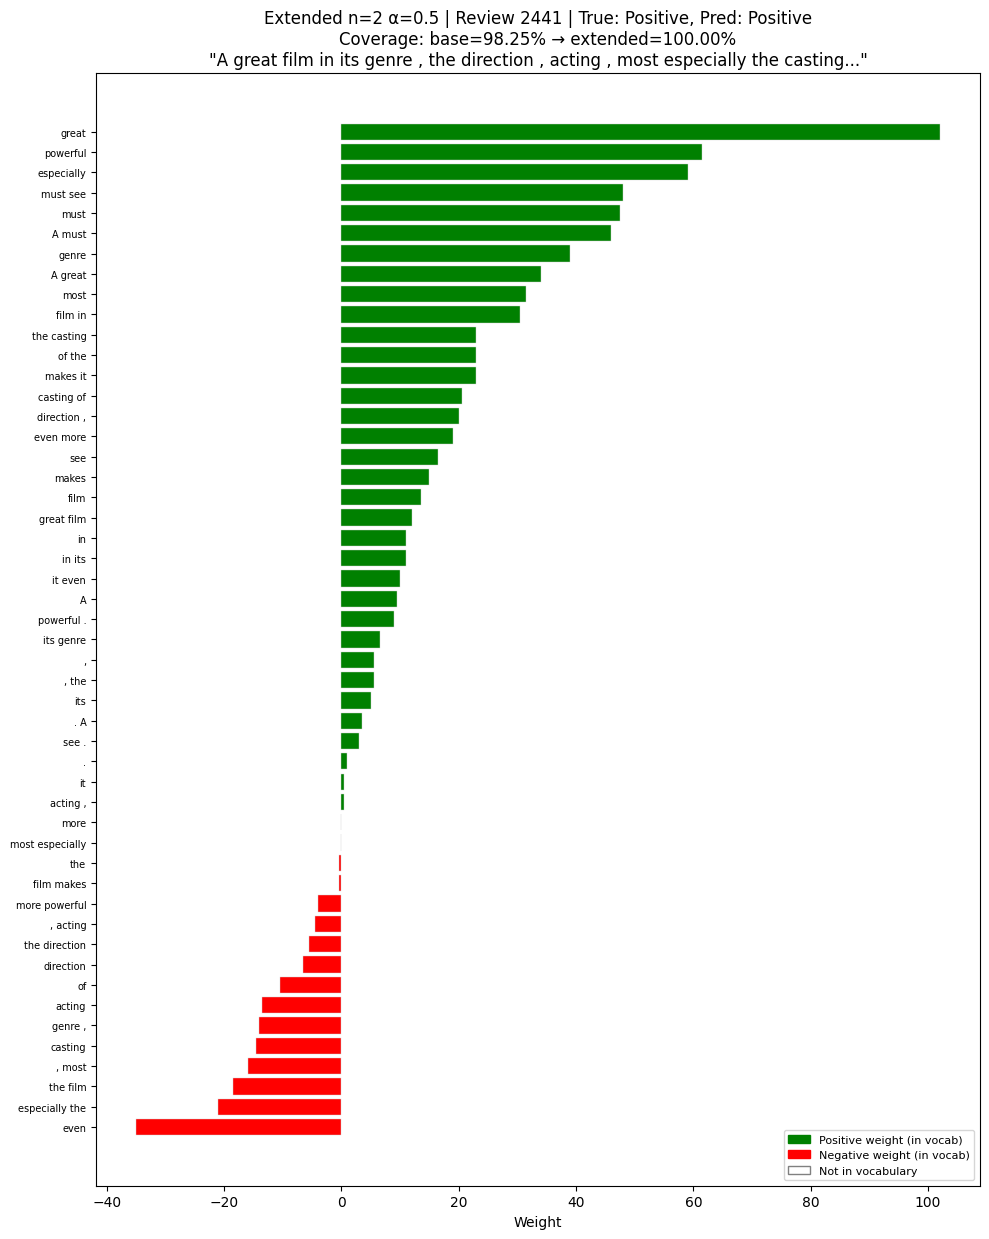

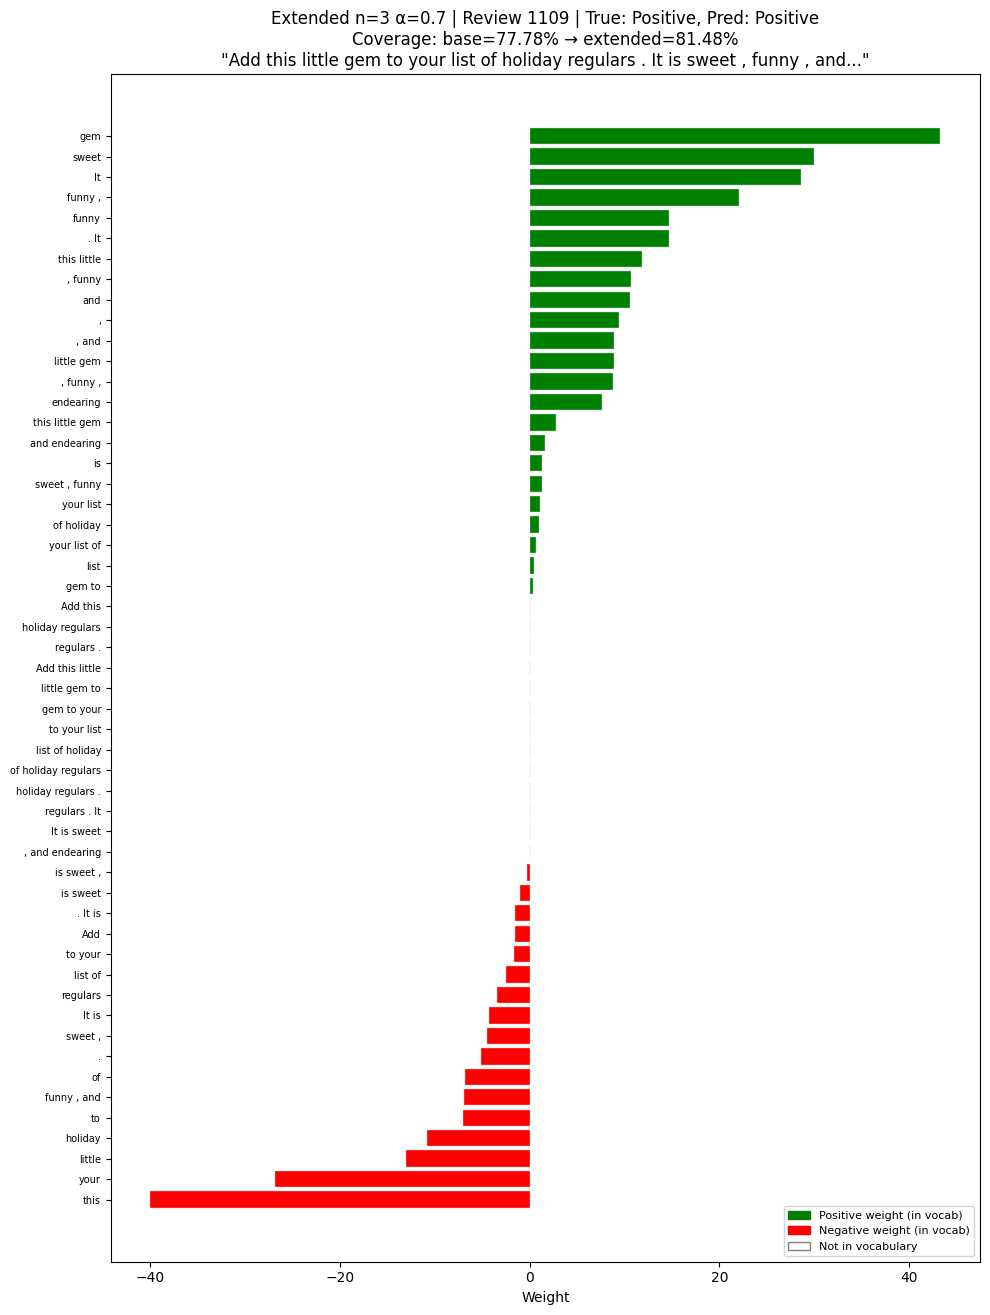

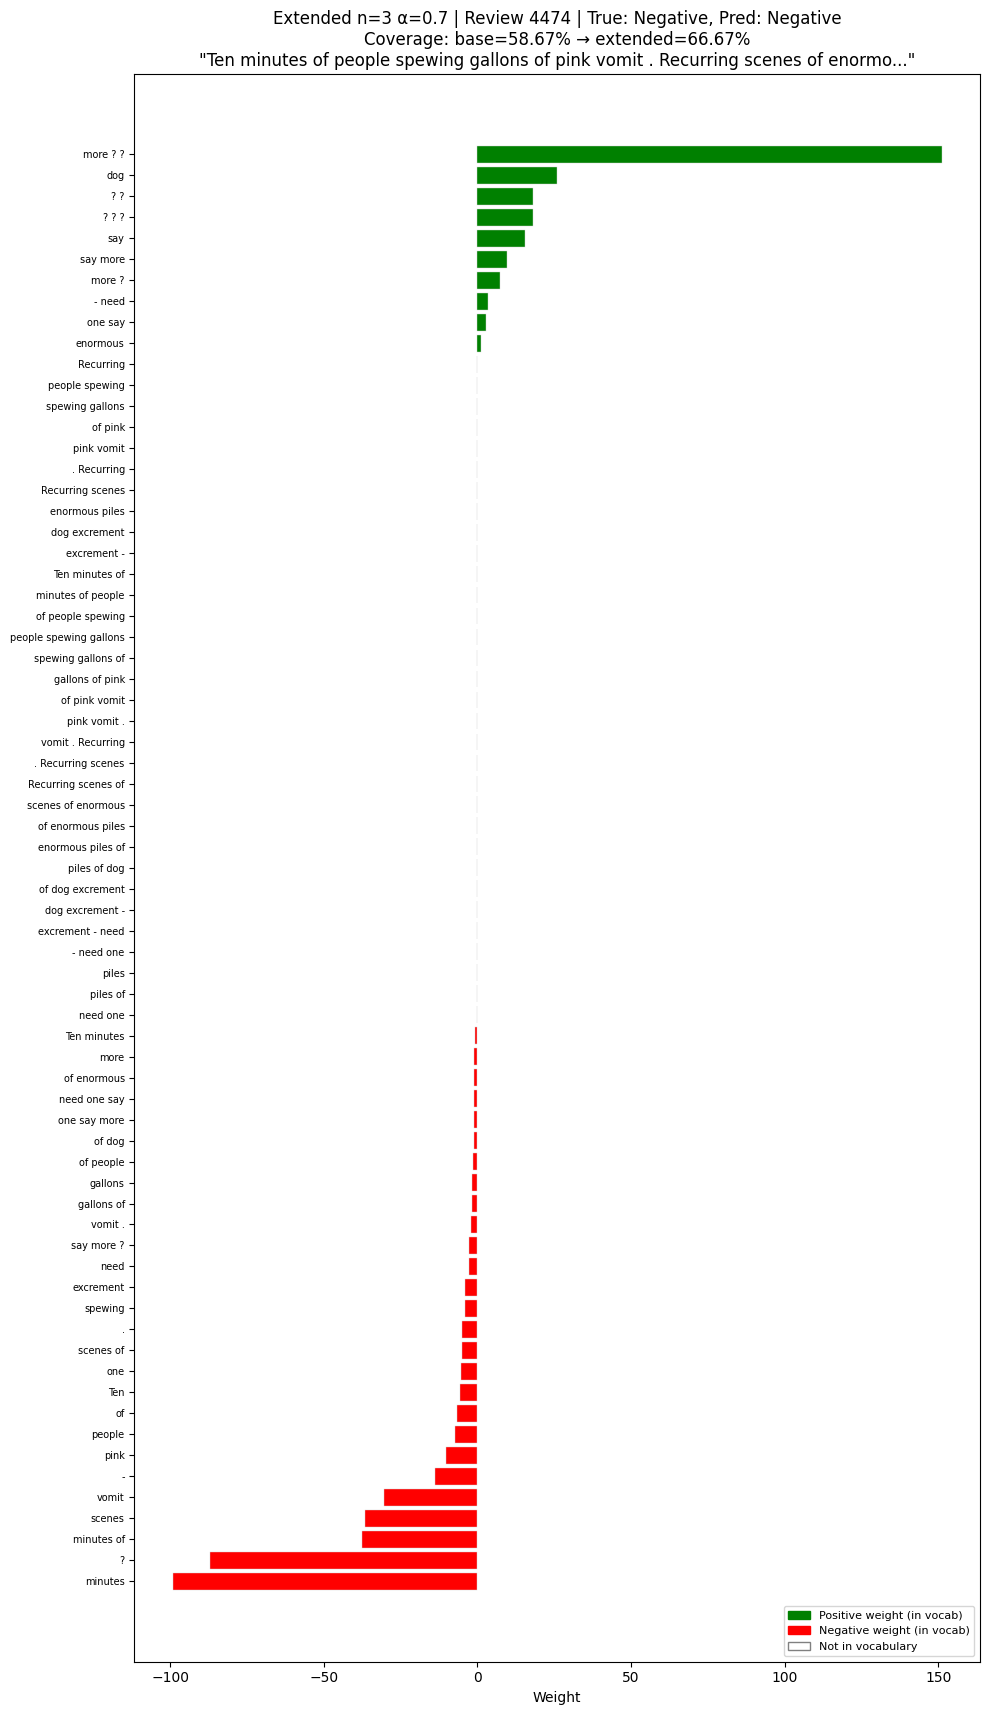

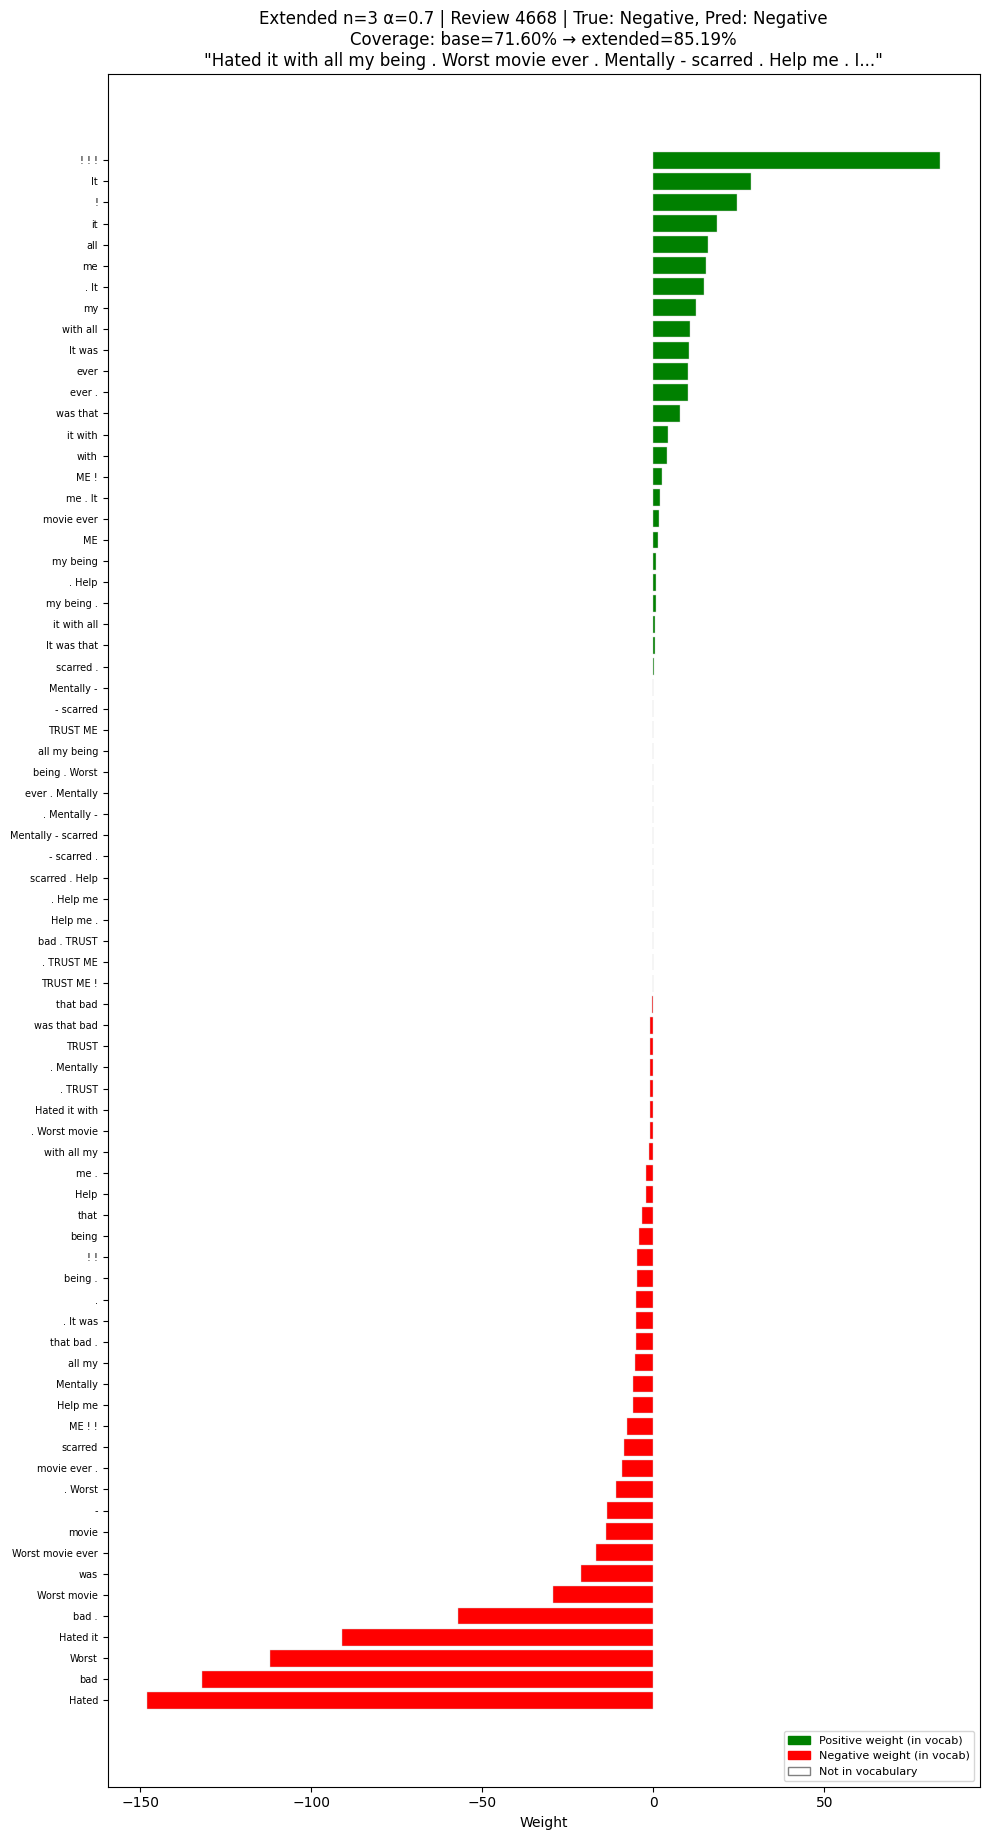

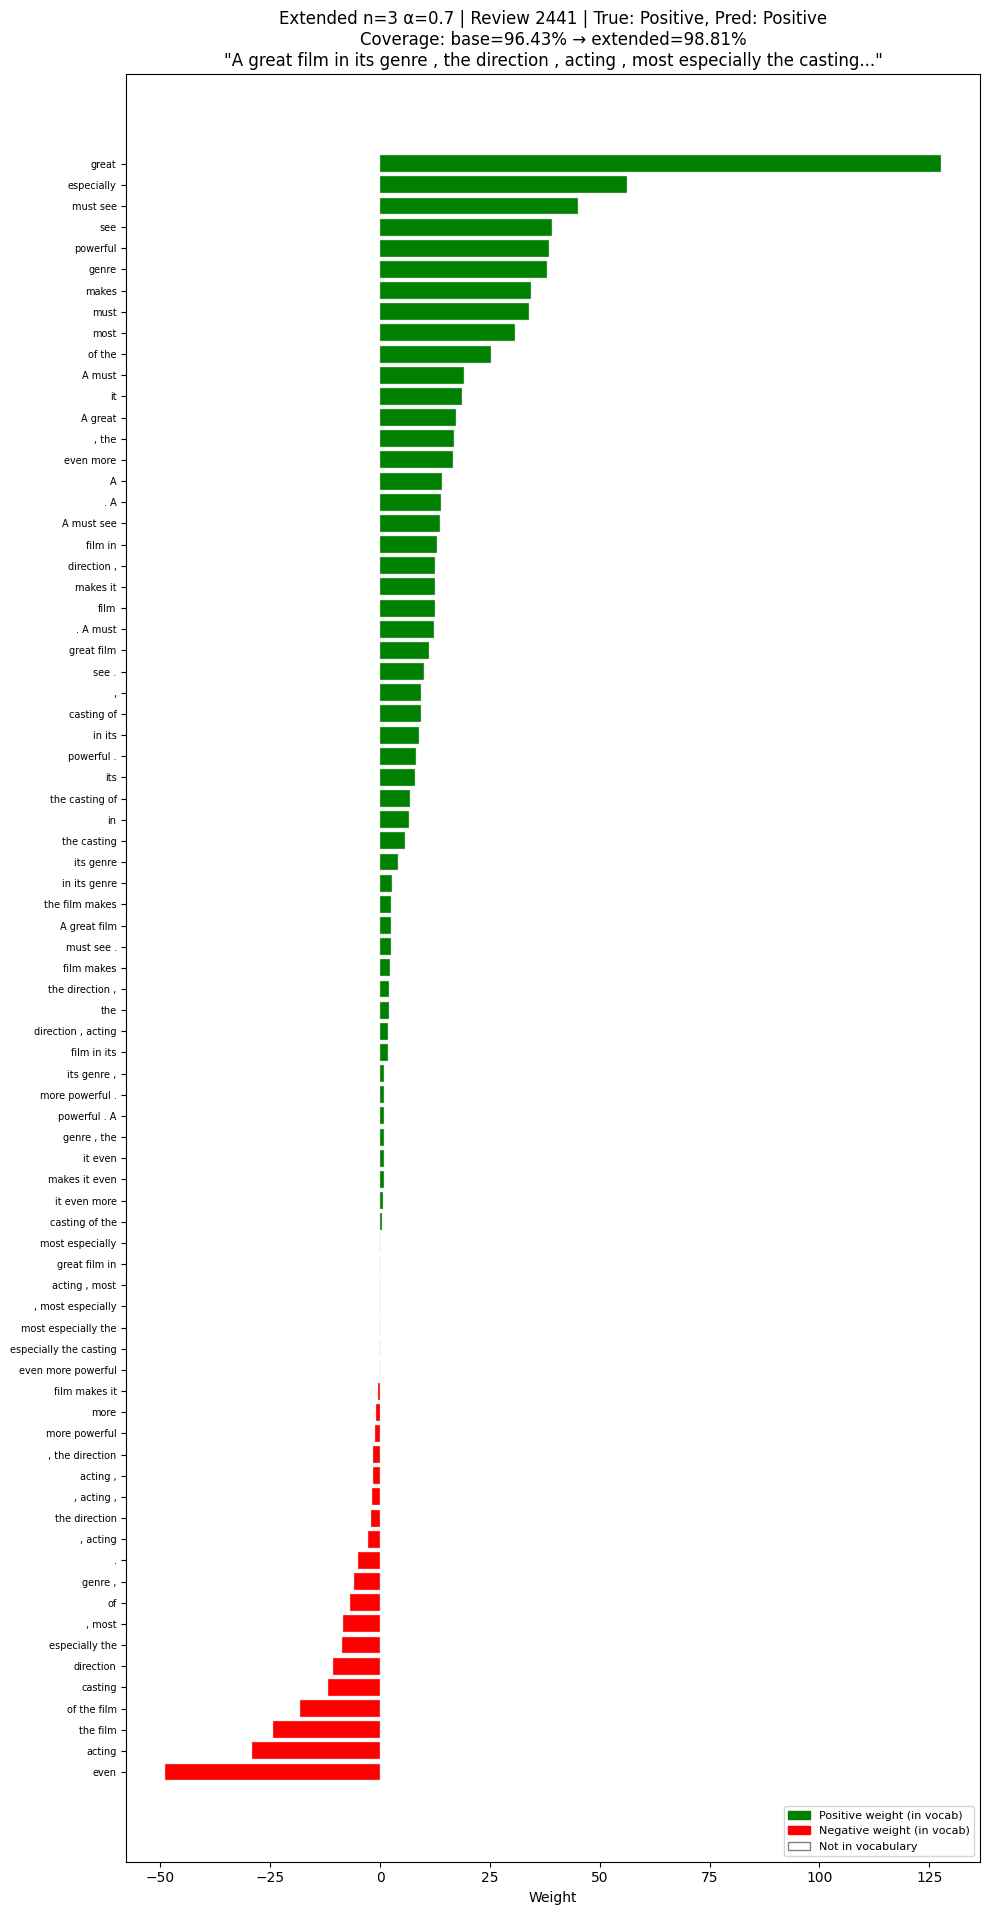


Coverage ratio comparison (base vs extended) on base test set
  n_max=1 | Base coverage: 0.9719 | Extended coverage: 0.9720 | Δ = +0.0001
  n_max=2 | Base coverage: 0.8414 | Extended coverage: 0.8653 | Δ = +0.0239
  n_max=3 | Base coverage: 0.7466 | Extended coverage: 0.7860 | Δ = +0.0394


In [18]:
# --- Rebuild combined models with best alpha per n_max ---
alpha_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
combined_best_models = {}

for n_max in n_max_values:
    base_model, base_vocab, base_cmin, _ = best_models[n_max]
    ext_model, ext_vocab, ext_cmin, _ = ext_best_models[n_max]

    # Build combined vocabulary
    all_ngrams = set(base_vocab.keys()) | set(ext_vocab.keys())
    combined_vocab = {ngram: idx for idx, ngram in enumerate(sorted(all_ngrams))}
    num_combined = len(combined_vocab)

    # Map weights into combined space
    base_weights = np.zeros(num_combined)
    base_ngram_set = set()
    for ngram, old_idx in base_vocab.items():
        base_weights[combined_vocab[ngram]] = base_model.weights[old_idx]
        base_ngram_set.add(ngram)

    ext_weights = np.zeros(num_combined)
    ext_ngram_set = set()
    for ngram, old_idx in ext_vocab.items():
        ext_weights[combined_vocab[ngram]] = ext_model.weights[old_idx]
        ext_ngram_set.add(ngram)

    # Find best alpha on base validation set
    X_val_combined = texts_to_sparse_features(val_texts, combined_vocab, n_max)
    best_alpha = 0
    best_alpha_acc = 0

    for alpha in alpha_values:
        cw = np.zeros(num_combined)
        for ngram, idx in combined_vocab.items():
            in_b = ngram in base_ngram_set
            in_e = ngram in ext_ngram_set
            if in_b and in_e:
                cw[idx] = alpha * base_weights[idx] + (1 - alpha) * ext_weights[idx]
            elif in_b:
                cw[idx] = base_weights[idx]
            else:
                cw[idx] = ext_weights[idx]
        cb = alpha * base_model.bias + (1 - alpha) * ext_model.bias
        m = LinearPerceptron(num_combined)
        m.weights = cw
        m.bias = cb
        preds = m.predict(X_val_combined)
        acc = accuracy(val_labels, preds)
        if acc > best_alpha_acc:
            best_alpha_acc = acc
            best_alpha = alpha

    # Build final combined model with best alpha
    final_weights = np.zeros(num_combined)
    for ngram, idx in combined_vocab.items():
        in_b = ngram in base_ngram_set
        in_e = ngram in ext_ngram_set
        if in_b and in_e:
            final_weights[idx] = best_alpha * base_weights[idx] + (1 - best_alpha) * ext_weights[idx]
        elif in_b:
            final_weights[idx] = base_weights[idx]
        else:
            final_weights[idx] = ext_weights[idx]
    final_bias = best_alpha * base_model.bias + (1 - best_alpha) * ext_model.bias

    final_model = LinearPerceptron(num_combined)
    final_model.weights = final_weights
    final_model.bias = final_bias

    combined_best_models[n_max] = (final_model, combined_vocab, best_alpha, best_alpha_acc)

# --- Test accuracy for all model types ---
deberta_test_acc = 0.9394  # From earlier DeBERTa evaluation

print(f"{'='*70}")
print(f"{'Model':<35} | {'Val Acc':>8} | {'Test Acc':>8}")
print(f"{'='*70}")

# DeBERTa
print(f"{'DeBERTa-v3 (LoRA fine-tuned)':<35} | {'—':>8} | {deberta_test_acc:>8.4f}")

# Base perceptron models
for n_max in n_max_values:
    model, vocab, c_min, val_acc = best_models[n_max]
    X_test_base = texts_to_sparse_features(test_texts, vocab, n_max)
    test_preds = model.predict(X_test_base)
    test_acc = accuracy(test_labels, test_preds)
    print(f"{'Base perceptron n=' + str(n_max) + ' c=' + str(c_min):<35} | {val_acc:>8.4f} | {test_acc:>8.4f}")

# Extended (combined) perceptron models
for n_max in n_max_values:
    comb_model, comb_vocab, best_a, val_acc = combined_best_models[n_max]
    X_test_comb = texts_to_sparse_features(test_texts, comb_vocab, n_max)
    test_preds = comb_model.predict(X_test_comb)
    test_acc = accuracy(test_labels, test_preds)
    print(f"{'Extended perceptron n=' + str(n_max) + ' α=' + str(best_a):<35} | {val_acc:>8.4f} | {test_acc:>8.4f}")

print(f"{'='*70}")

# --- Visualization for the same 4 short reviews ---
print(f"\n{'='*60}")
print("Visualization of extended models on the same 4 short reviews")
print(f"{'='*60}")

for n_max in n_max_values:
    comb_model, comb_vocab, best_a, _ = combined_best_models[n_max]
    base_model_b, base_vocab_b, _, _ = best_models[n_max]

    for idx, label, text in short_reviews:
        sentiment = "Positive" if label == 1 else "Negative"
        pred = comb_model.predict_one(texts_to_sparse_features([text], comb_vocab, n_max)[0])
        pred_str = "Positive" if pred == 1 else "Negative"

        # Coverage comparison
        ngrams = get_ngrams(text, n_max)
        base_covered = sum(1 for ng in ngrams if ng in base_vocab_b)
        ext_covered = sum(1 for ng in ngrams if ng in comb_vocab)
        total = len(ngrams)
        base_cov = base_covered / total if total > 0 else 0
        ext_cov = ext_covered / total if total > 0 else 0

        title = (
            f"Extended n={n_max} α={best_a} | Review {idx} | "
            f"True: {sentiment}, Pred: {pred_str}\n"
            f"Coverage: base={base_cov:.2%} → extended={ext_cov:.2%}\n"
            f'"{text[:80]}..."'
        )
        plot_ngram_weights(text, comb_model, comb_vocab, n_max, title=title)

# --- Coverage ratio for extended models over base test set ---
print(f"\n{'='*60}")
print("Coverage ratio comparison (base vs extended) on base test set")
print(f"{'='*60}")

for n_max in n_max_values:
    _, base_vocab_b, base_cmin, _ = best_models[n_max]
    _, comb_vocab, best_a, _ = combined_best_models[n_max]

    base_total, base_covered = 0, 0
    ext_total, ext_covered = 0, 0
    for text in test_texts:
        ngrams = get_ngrams(text, n_max)
        base_total += len(ngrams)
        base_covered += sum(1 for ng in ngrams if ng in base_vocab_b)
        ext_total += len(ngrams)
        ext_covered += sum(1 for ng in ngrams if ng in comb_vocab)
    base_cov = base_covered / base_total
    ext_cov = ext_covered / ext_total
    print(f"  n_max={n_max} | Base coverage: {base_cov:.4f} | Extended coverage: {ext_cov:.4f} | Δ = +{ext_cov - base_cov:.4f}")

## Discussion
Using the DeBERTa model we get an accuracy score of `0.9394`, while using the linear perceptron we get the highest accuracy score of `0.8830` with n_max = 2 and c_min = 3. The difference in performance is thus quite small, but not insignificant. If one simply values performance and the highest possible accuracy above all, then the DeBERTa model is the clear choice. However, reality is often times more complex than that, and interpretability is quite often important as well. Therefore the linear perceptron also has value as a classifier. It provides a similar performance while being easy to understand and explainable. One can also see exactly how each unigram or bigram affects the end result. This information is also valuable and brings insight into how the classifier thinks and reasons.

### Extended vs Base Perceptron Models
Training on the extended dataset and combining the weights via the alpha-weighted formula generally improves both accuracy and coverage. The extended models have access to a larger vocabulary since they are trained on more data, which means more n-grams from the test set are recognized and contribute to the prediction. This is reflected in the coverage ratio increase. The improvement is particularly noticeable for higher n values (bigrams and trigrams), where the base training set may not contain enough examples of multi-word patterns.

The alpha parameter controls the trade-off between the base and extended model weights. When alpha is close to 1, the combined model trusts the base model more; when close to 0, it trusts the extended model more. The optimal alpha varies per n_max, suggesting that the relative quality of base vs extended training differs depending on the n-gram level.

### Overall Comparison
DeBERTa-v3 remains the best performer in terms of raw accuracy, benefiting from pre-trained contextual representations and attention mechanisms that capture long-range dependencies. The base perceptron models offer full interpretability at the cost of some accuracy. The extended perceptron models close the accuracy gap slightly while maintaining interpretability, and their increased coverage means fewer unseen n-grams during inference. In practical applications where model transparency, auditability, or explainability are required, the perceptron models present a compelling alternative despite the accuracy difference.